In [ ]:
!pip install matplotlib numpy scikit-learn scikit-opt pandas

: 

# Instalando Pacotes Necessários e Instanciando Datasets

Instancio os Datasets e faço a estandartização: 

$$
z = \frac{x - \mu}{\sigma}
$$

Para fazer a distribuição (discreta) das amostras ter média 0 e variância 1. Utilizo os mesmos datasets de Treino e Teste em todas redes neurais (MLP, ELM).

In [2]:
import math
from functools import partial
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    precision_score,
    # roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sko.PSO import PSO
from dataclasses import dataclass
from time import time



breast = load_breast_cancer()
x_breast = breast.data
y_breast = breast.target

wine = load_wine()
x_wine = wine.data
y_wine = wine.target

# Preparando DataSet do Breast
x_breast_train, x_breast_test, y_breast_train, y_breast_test = train_test_split(
    x_breast, y_breast,
    test_size=0.3,
)
scaler = StandardScaler() # Faz estandartização -> média = 0 e variância = 1
scaler.fit(x_breast_train)

x_breast_train = scaler.transform(x_breast_train)
x_breast_test = scaler.transform(x_breast_test)

# Preparando DataSet do Wine
x_wine_train, x_wine_test, y_wine_train, y_wine_test = train_test_split(
    x_wine, y_wine,
    test_size=0.3,
)
scaler = StandardScaler()
scaler.fit(x_wine_train)

x_wine_train = scaler.transform(x_wine_train)
x_wine_test = scaler.transform(x_wine_test)


# Configuração da camada oculta

Em todas as redes neurais a seguir, a quantidade de neurônios na camada oculta é 5x maior que o número de características do dataset. A hipótese é que o modelo aprenda uma transformação não linear dos dados, e portanto melhore a separabilidade das classes neste espaço 5*N-dimensional, conseguindo classificar as classes de forma mais precisa.

A seguir é feito o treinamento das redes MLP, utilizando backpropagation, para os dataset "breast_cancer" e "wine".

# Treinando o Breast MLP

In [10]:
def TrainMLP(
    x : np.ndarray,
    y : np.ndarray,
    hidden_layer_mult: float = 5.0,
    verbose : bool = True,
    max_it: int = 5000, 
    n_iter_no_change: int = 100,
) -> MLPClassifier:
    n_feat = x.shape[1]
    # https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_net
    # https://scikit-learn.org/stable/modules/neural_networks_supervised.html#classification Usa backprop
    mlp = MLPClassifier(
        hidden_layer_sizes=(n_feat*int(hidden_layer_mult),1), # Extração de Características
        activation='logistic', # sigmoide
        solver='adam', # heurística de cálculo de gradiente como Adagrad/Nadam/etc...
        learning_rate='constant',
        learning_rate_init=0.001,
        max_iter=max_it,
        n_iter_no_change=n_iter_no_change,
        tol=1e-4,
        verbose=verbose,
        batch_size=len(x) # fazer o cálculo do gradiente médio com todas as amostras
    )
    mlp.fit(x,y)

    return mlp

def classifier_metrics(
    model,
    x_test: np.ndarray,
    y_test: np.ndarray,
    average: str | None = "binary",
    zero_division : int = 0,    
) -> dict:
    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred,average=average)
    precision = precision_score(y_test, y_pred,average=average,zero_division=zero_division)
    f1 = f1_score(y_test, y_pred,average=average)
    metrics = {
        "y_pred" : y_pred,
        "accuracy" : accuracy,
        "recall" : recall,
        "precision" : precision,
        "f1" : f1,
    }
    return metrics

def test_classifier(
    ax,
    x_test : np.ndarray,
    y_test : np.ndarray,
    model,
    text: str,
    display_labels : list | None = ['True', 'False'],
    average: str | None = "binary",
    zero_division : int = 0,
) -> tuple[np.ndarray,list,list]:
    
    metrics = classifier_metrics(
        model=model,
        x_test=x_test,
        y_test=y_test,
        average=average,
        zero_division=zero_division,
    )
    # roc_auc = roc_auc_score(y_test,y_pred) # Professor não pediu
    cm = confusion_matrix(y_test, metrics["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(
        ax=ax,
        cmap='Blues',
        values_format='d',
        colorbar=True
    )
    ax.set_title(f'Confusion Matrix ({text})', fontsize=12, fontweight='bold')
    ax.set_ylabel("")
    ax.set_xlabel(
        f"Accuracy={metrics['accuracy']:.3f} | "
        f"Precision={metrics['precision']:.3f} | \n"
        f"Recall={metrics['recall']:.3f} |"
        f"F1={metrics['f1']:.3f} | "
        # f"ROC-AUC={roc_auc:.3f}" # Professor não pediu
    )



Iteration 1, loss = 0.78764838
Iteration 2, loss = 0.78144636
Iteration 3, loss = 0.77530426
Iteration 4, loss = 0.76925954
Iteration 5, loss = 0.76334810
Iteration 6, loss = 0.75760357
Iteration 7, loss = 0.75205654
Iteration 8, loss = 0.74673353
Iteration 9, loss = 0.74165634
Iteration 10, loss = 0.73684159
Iteration 11, loss = 0.73230051
Iteration 12, loss = 0.72803902
Iteration 13, loss = 0.72405794
Iteration 14, loss = 0.72035340
Iteration 15, loss = 0.71691751
Iteration 16, loss = 0.71373891
Iteration 17, loss = 0.71080361
Iteration 18, loss = 0.70809563
Iteration 19, loss = 0.70559768
Iteration 20, loss = 0.70329179
Iteration 21, loss = 0.70115985
Iteration 22, loss = 0.69918400
Iteration 23, loss = 0.69734702
Iteration 24, loss = 0.69563258
Iteration 25, loss = 0.69402538
Iteration 26, loss = 0.69251133
Iteration 27, loss = 0.69107753
Iteration 28, loss = 0.68971234
Iteration 29, loss = 0.68840529
Iteration 30, loss = 0.68714710
Iteration 31, loss = 0.68592958
Iteration 32, los

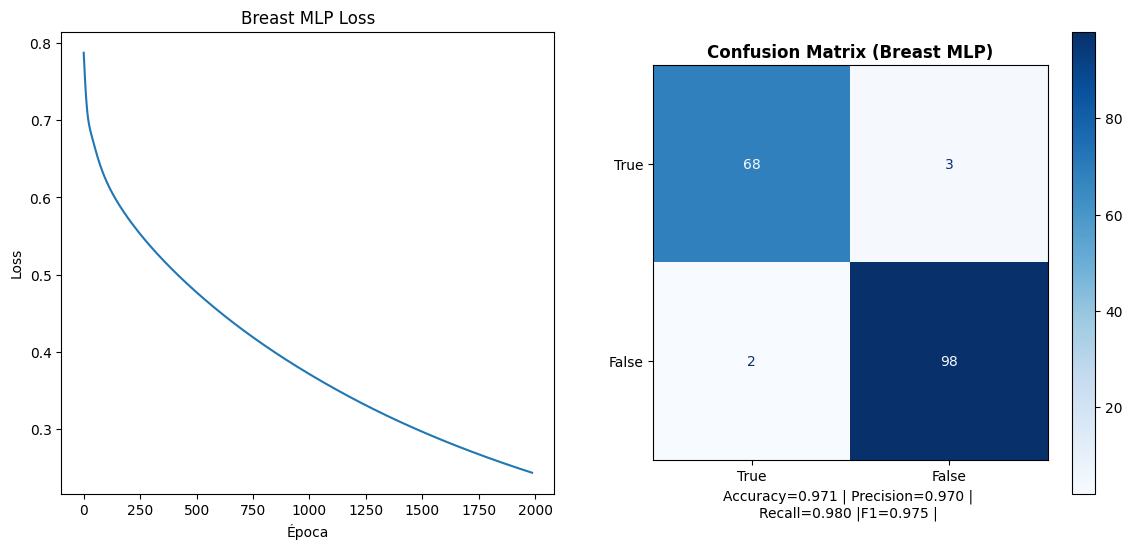

In [102]:

breast_mlp = TrainMLP(
    x=x_breast_train,
    y=y_breast_train 
)
_, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].plot(breast_mlp.loss_curve_)
ax[0].set_title("Breast MLP Loss")
ax[0].set_xlabel("Época")
ax[0].set_ylabel("Loss")
test_classifier(ax[1],x_breast_test,y_breast_test,breast_mlp,"Breast MLP")
plt.show()

# Resultado Breast MLP

Como mostrado pela Matriz de Confusão, a rede treinada conseguiu separar bem as duas classes neste espaço 5N-dimensional para o dataset do "breast_cancer". Porém é importante ressaltar que o backpropagation é um algorítmo de otimização local, ou seja, o algorítmo é extremamente dependente das condições iniciais, neste caso tais condições são os pesos iniciados aleatoriamente. Posteriormente será realizado um teste de robustez, e depois será feito a média dos resultados, testando o quão a solução é robusta à mudanças das condições iniciais, por esse principal motivo, nenhuma 'seed' é fixada neste trabalho.

# Treinando o Wine MLP

Iteration 1, loss = 1.19486367
Iteration 2, loss = 1.19191757
Iteration 3, loss = 1.18901083
Iteration 4, loss = 1.18614610
Iteration 5, loss = 1.18332610
Iteration 6, loss = 1.18055348
Iteration 7, loss = 1.17783073
Iteration 8, loss = 1.17516021
Iteration 9, loss = 1.17254409
Iteration 10, loss = 1.16998437
Iteration 11, loss = 1.16748282
Iteration 12, loss = 1.16504099
Iteration 13, loss = 1.16266019
Iteration 14, loss = 1.16034149
Iteration 15, loss = 1.15808573
Iteration 16, loss = 1.15589346
Iteration 17, loss = 1.15376502
Iteration 18, loss = 1.15170050
Iteration 19, loss = 1.14969972
Iteration 20, loss = 1.14776232
Iteration 21, loss = 1.14588768
Iteration 22, loss = 1.14407499
Iteration 23, loss = 1.14232323
Iteration 24, loss = 1.14063120
Iteration 25, loss = 1.13899755
Iteration 26, loss = 1.13742074
Iteration 27, loss = 1.13589914
Iteration 28, loss = 1.13443098
Iteration 29, loss = 1.13301439
Iteration 30, loss = 1.13164744
Iteration 31, loss = 1.13032813
Iteration 32, los

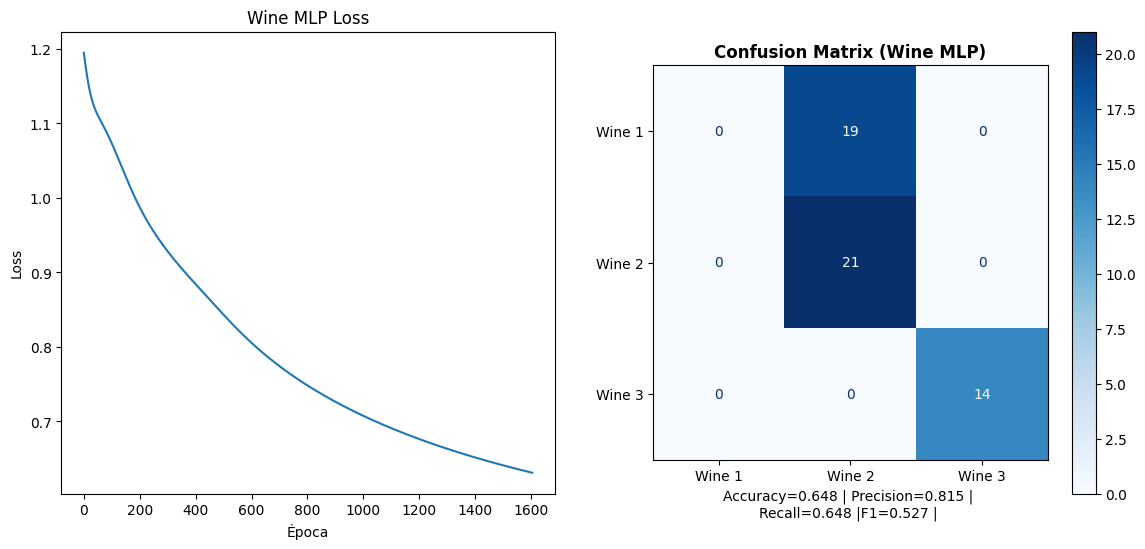

In [122]:
wine_mlp = TrainMLP(
    x=x_wine_train,
    y=y_wine_train 
)

_, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].plot(wine_mlp.loss_curve_)
ax[0].set_title("Wine MLP Loss")
ax[0].set_xlabel("Época")
ax[0].set_ylabel("Loss")
test_classifier(ax[1],x_wine_test,y_wine_test,wine_mlp,"Wine MLP",display_labels=["Wine 1","Wine 2","Wine 3"],average="weighted",zero_division=1)
plt.show()

# Resultado Wine MLP

Como mostrado pela Matriz de Confusão, a rede treinada não conseguiu separar bem as duas classes neste espaço 5N-dimensional para o dataset do "wine". Como explicado anteriormente o backpropagation é dependente das condições iniciais, o que pode explicar a má perfomance neste caso.

# Implementação da ELM

A Extreme Learning Machine (ELM) é uma rede neural de 3 camadas, uma camada de entrada, uma camada oculta e uma camada de saída. Na ELM os pesos entre a camada de entrada e a camada oculta não são treinados, são iniciados aleatóriamente, e os pesos entre a camada oculta e a camada de sáida são treinados usando a pseudoinversa:

$$
H = (X^{T}X)^{-1}X^{T}Y
H = X^{+} Y
$$

Podemos usar o Particle Swarm Optimization (PSO) para fazer uma exploração no espaço de busca, efetivamente buscando um bom $$H$$. Segue abaixo a implementação e seu treinamento para os dataset de 'breast_cancer' e 'wine'.

In [14]:
# Não encontrei Libs, mas como é simples de implementar ...
class CustomELM:
    def __init__(self, discriminative_func, n_hidden : int | None = 10, W : np.ndarray | None = None):
        self.n_hidden = n_hidden
        self.W = W
        self.discriminative_func=discriminative_func

    def _sigmoid(self, x):
        x = np.clip(x, -50, 50) # evitar overflow
        return 1 / (1 + np.exp(-x))

    def fit(self, x, y, one_hot=False): # bias será imbutido em X
        x = np.hstack([x, np.ones((x.shape[0], 1))]) # Incializa um vetor de N_samples com valores 1, e coloca na direta do vetor inicial
        if self.W is None:
            self.W = np.random.randn(x.shape[1], self.n_hidden)
        
        if one_hot:
            y = to_one_hot(y)

        hidden_activation = self._sigmoid(x @ self.W) # Cálculo da camada intermediária
        self.hidden_W = np.linalg.pinv(hidden_activation) @ y # Cálculo da camada de saída (pseudoinversa)

    def predict(self, x):
        x = np.hstack([x, np.ones((x.shape[0], 1))])
        hidden_activation = self._sigmoid(x @ self.W)
        y = hidden_activation @ self.hidden_W
        y = self.discriminative_func(y) # Função discriminativa, para fazer a escolha da classe
        return y
    
    def score(self,x_test,y_test,average="binary"):
        y_pred = self.predict(x_test)
        # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html#sklearn.metrics.f1_score
        return f1_score(y_test, y_pred, average=average)

def binary_pred(
    y: np.ndarray,
) -> np.ndarray:
    return (y >= 0.5).astype(int) # Como no breast é binário

def one_hot_pred(
    y: np.ndarray,
) -> np.ndarray:
    softmax = []
    for y_array in y:
        den = 0
        score = []
        for y_val in y_array:
            y_val = np.clip(y_val, -50, 50) # evitar overflow
            den+=math.e**y_val
        for y_val in y_array:
            y_val = np.clip(y_val, -50, 50)
            score.append((math.e**y_val)/den)
        softmax.append(np.array(score))

    pred = []
    for score in softmax:
        pred.append(np.argmax(score)) 
    
    return np.array(pred)

def to_one_hot(
    y_array: np.ndarray
) -> None:
    n_classes = len(np.unique(y_array))
    y = np.eye(n_classes)[y_array] # transforma tudo para one-hot
    return y

def _fitness(weights,hidden_size,input_size,one_hot,discriminative_func,average,x_train,y_train,orthogonal_restriction=False):

    W = np.reshape(weights,(input_size,hidden_size))
    elm = CustomELM(W=W,discriminative_func=discriminative_func)
    elm.fit(x_train,y_train,one_hot)
    fitness = 1.0 - elm.score(x_train,y_train,average)
    if orthogonal_restriction:
        # https://numpy.org/doc/2.1/reference/generated/numpy.linalg.matrix_norm.html
        if hidden_size > input_size:
            fitness = fitness + np.linalg.matrix_norm(W @ W.T - np.eye(input_size),ord='fro')
        else:
            fitness = fitness + np.linalg.matrix_norm(W.T @ W - np.eye(hidden_size),ord='fro')

    return fitness # PSO minimiza a fitness, como o f1 varia de 0 a 1, basta substrair de um o score

def ELMTraining(
    x : np.ndarray,
    y : np.ndarray,
    discriminative_func : Callable,
    average : str = "binary",
    one_hot : bool = False,
    orthogonal_restriction : bool = False,
    max_it : int = 5000,
    tol : float = 1000.0,
    steps: int = 100,
    verbose: bool = True,
    hidden_layer_mult: int = 5.0,
    simetric_bound: float = 1e2,
) -> tuple[float,float,float] :
    
    max_it = (max_it // 100) * 100 # Deixa o max_it como multiplo de 100
    N_PARTICLES=20 # Paper -> Entre 20-50

    fitness = partial(
        _fitness,
        hidden_size=int(x.shape[1]*hidden_layer_mult),
        input_size=int(x.shape[1]+1),
        one_hot=one_hot,
        discriminative_func=discriminative_func,
        average=average,
        x_train=x,
        y_train=y,
        orthogonal_restriction=orthogonal_restriction
    )

    particle_dimension = int( (x.shape[1]*hidden_layer_mult) * (x.shape[1]+1))
    # Tinha deixado bem grande o espaço de busca, mas nas otimizações ortonais estava demorando muito...
    lb = -simetric_bound * np.ones(particle_dimension) # Virtualmente sem restrições
    ub = simetric_bound * np.ones(particle_dimension) # Virtualmente sem restrições

    pso = PSO(
        func=fitness,
        n_dim=particle_dimension,
        pop=N_PARTICLES,
        max_iter=steps,
        lb=lb,
        ub=ub,
        w=0.8, # w < 1
        c1=1.5, # c1 E [1,3]
        c2=1.5, # c2 E [1,3]
    )
    
    best_score = None
    previous_step_best_score = None
    runs = 0
    # start_time = time()
    while runs < max_it:
        pso.run()
        runs+=steps
        if best_score is None or pso.gbest_y.item() < best_score:
            if best_score is None:
                previous_step_best_score = pso.gbest_y.item()
            else:
                previous_step_best_score=best_score
            best_score = pso.gbest_y.item()
        if runs > steps and (pso.gbest_y.item() > best_score or previous_step_best_score-best_score <= tol):
            print(f"Stopping PSO, did not found better solution after {steps} steps")
            break
        if best_score == 0.0:
            print(f"Stopping PSO, found the best solution after {runs} runs")
            break
        if verbose:
            print(f"Current Iteration {runs}, Best Score {best_score:.5f}, Fitness Diff = {best_score-previous_step_best_score}")



        
    # print(f"Runtime = {time()-start_time}")

    best_weights = pso.gbest_x
    best_score = pso.gbest_y.item()

    print(f"Best Score Achieved : {best_score}")

    return best_weights,best_score,runs

# Breast ELM-PSO

Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0


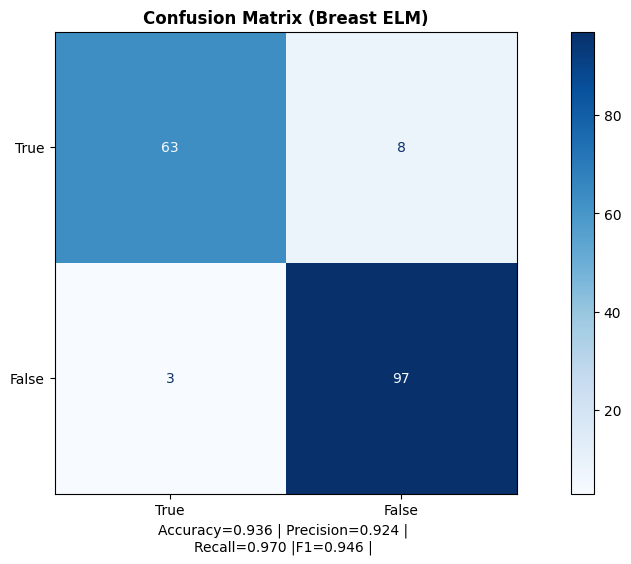

In [112]:
best_weights,_,_ = ELMTraining(
    x=x_breast_train,
    y=y_breast_train,
    discriminative_func=binary_pred,
)
_, ax = plt.subplots(1, 1, figsize=(14, 6))
elm_breast = CustomELM(W=best_weights.reshape(x_breast.shape[1]+1,x_breast.shape[1]*5), discriminative_func=binary_pred)
elm_breast.fit(x_breast_train,y_breast_train)
test_classifier(ax,x_breast_test,y_breast_test,elm_breast,"Breast ELM", average="binary")


# Resultado Breast ELM-PSO

Comparando os resultados com o Breast MLP, é perceptível que os resultados são parecidos, uma explicação plausível seria que em todo o espaço de busca 5N-dimensional do "breast_cancer" há muitos bons mínimos locais, ou em outras palavras, há muitas opções de uma boa separabilidade das classes do dataset de "breast_cancer" neste espaço 5N-dimensional, e portanto, pouco importa o estado inicial da camada oculta no caso do MLP.

# Wine ELM-PSO

Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0


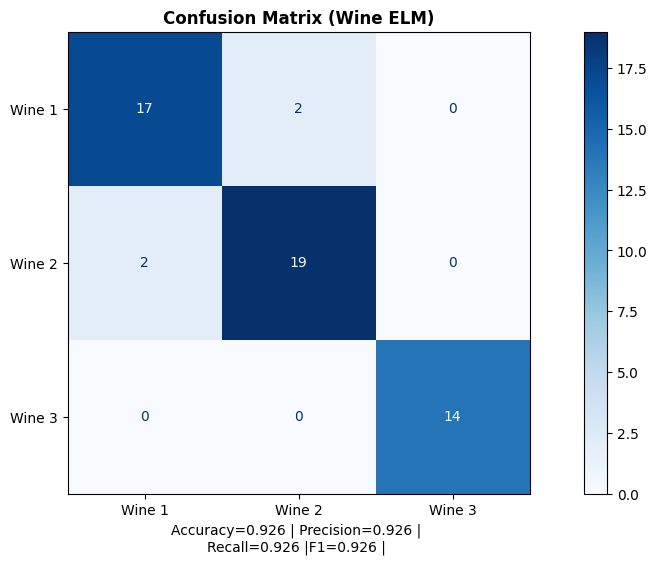

In [113]:
best_weights,_,_ = ELMTraining(
    x=x_wine_train,
    y=y_wine_train,
    discriminative_func=one_hot_pred,
    average="weighted",
    one_hot=True,
)
_, ax = plt.subplots(1, 1, figsize=(14, 6))
elm_wine = CustomELM(W=best_weights.reshape(x_wine.shape[1]+1,x_wine.shape[1]*5), discriminative_func=one_hot_pred)
elm_wine.fit(x_wine_train,y_wine_train, one_hot=True)
test_classifier(ax,x_wine_test,y_wine_test,elm_wine,"Wine ELM",display_labels=["Wine 1","Wine 2","Wine 3"],average="weighted")

# Resultado Wine ELM-PSO

Comparando os resultados com o Wine MLP, é perceptível que os resultados são bem diferentes. Uma hipótese para esta diferença de desempenho está na separabilidade das classes no espaço 5N-Dimensional, ou seja, neste espaço há poucos bons ótimos locais, implicando que o Backpropagation tenha desempenho significativamente pior do que o ELM-PSO, pois é fortemente dependente das condições iniciais dos seus pesos. Já o ELM-PSO consegue fazer a exploração do espaço de busca, resultando em melhores mínimos locais, ou em outras palavras, pesos que conseguem melhorar as separabilidade das classes neste espaço 5N-dimensional.

# ELM com Restrição de Ortogonalidade

A restrição de ortogonalidade na função de fitness obriga o PSO a procurar pesos que são ortogonais entre si. A ortogonalidade pode ajudar a cada conjunto de pesos codificar características diferentes, melhorando a separabilidade das classes, e portanto a generalização do modelo. Segue os testes abaixo.

# Breast ELM com Restrição de Ortogonalidade

Current Iteration 100, Best Score 4406025.33213, Fitness Diff = 0.0
Current Iteration 200, Best Score 4398680.31959, Fitness Diff = -7345.012541132979
Current Iteration 300, Best Score 4389172.62777, Fitness Diff = -9507.691819935106
Current Iteration 400, Best Score 4381831.02745, Fitness Diff = -7341.6003236752
Current Iteration 500, Best Score 4369431.36441, Fitness Diff = -12399.663037433289
Current Iteration 600, Best Score 4349206.68762, Fitness Diff = -20224.67678823881
Current Iteration 700, Best Score 4334637.29040, Fitness Diff = -14569.397222578526
Current Iteration 800, Best Score 4320643.51937, Fitness Diff = -13993.771030602977
Current Iteration 900, Best Score 4313875.88043, Fitness Diff = -6767.638934168965
Current Iteration 1000, Best Score 4305492.10118, Fitness Diff = -8383.779251813889
Current Iteration 1100, Best Score 4289723.78646, Fitness Diff = -15768.314717997797
Current Iteration 1200, Best Score 4279323.63707, Fitness Diff = -10400.149390471168
Current Itera

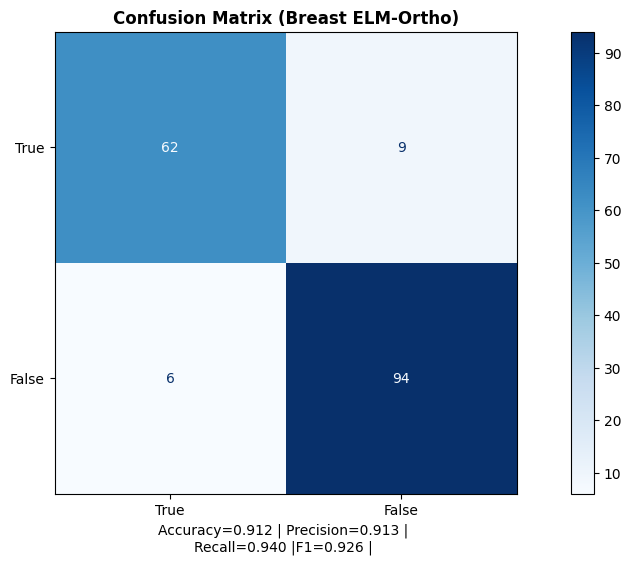

In [114]:
best_weights,_,_ = ELMTraining(
    x=x_breast_train,
    y=y_breast_train,
    discriminative_func=binary_pred,
    orthogonal_restriction=True,
)
_, ax = plt.subplots(1, 1, figsize=(14, 6))
elm_breast = CustomELM(W=best_weights.reshape(x_breast.shape[1]+1,x_breast.shape[1]*5), discriminative_func=binary_pred)
elm_breast.fit(x_breast_train,y_breast_train)
test_classifier(ax,x_breast_test,y_breast_test,elm_breast,"Breast ELM-Ortho", average="binary")

# Resultado Breast ELM-PSO-Ortho

Comparando com os resultados do ELM sem restrição e com o MLP, é notável que não há diferença significativa entre eles, uma vez que neste espaço 5N-dimensional há muitas possíveis boas maneiras de separar as classes do "breast_cancer", e portanto esta estratégia de otimização aparenta não produz ganhos relevantes quando se comparado com as demais.

# ELM Wine com Restrição de Ortogonalidade

Current Iteration 100, Best Score 1174682.01140, Fitness Diff = 0.0
Current Iteration 200, Best Score 1160661.37584, Fitness Diff = -14020.635566773824
Current Iteration 300, Best Score 1146238.16653, Fitness Diff = -14423.209307604702
Current Iteration 400, Best Score 1126956.66805, Fitness Diff = -19281.49847985455
Current Iteration 500, Best Score 1113857.45944, Fitness Diff = -13099.208608713001
Current Iteration 600, Best Score 1094828.88026, Fitness Diff = -19028.579179299995
Current Iteration 700, Best Score 1087366.87222, Fitness Diff = -7462.008043163456
Current Iteration 800, Best Score 1077269.53970, Fitness Diff = -10097.332512215246
Current Iteration 900, Best Score 1068702.54930, Fitness Diff = -8566.990409174701
Current Iteration 1000, Best Score 1059238.49114, Fitness Diff = -9464.058159757638
Current Iteration 1100, Best Score 1052043.81605, Fitness Diff = -7194.6750904947985
Current Iteration 1200, Best Score 1040006.27630, Fitness Diff = -12037.539742950117
Current I

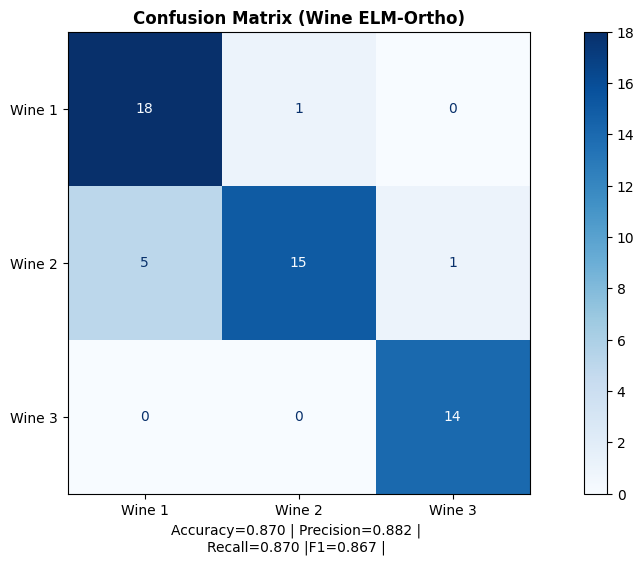

In [115]:
best_weights,_,_ = ELMTraining(
    x=x_wine_train,
    y=y_wine_train,
    discriminative_func=one_hot_pred,
    average="weighted",
    one_hot=True,
    orthogonal_restriction=True,
)

_, ax = plt.subplots(1, 1, figsize=(14, 6))
elm_wine = CustomELM(W=best_weights.reshape(x_wine.shape[1]+1,x_wine.shape[1]*5), discriminative_func=one_hot_pred)
elm_wine.fit(x_wine_train,y_wine_train, one_hot=True)
test_classifier(ax,x_wine_test,y_wine_test,elm_wine,"Wine ELM-Ortho",display_labels=["Wine 1","Wine 2","Wine 3"],average="weighted")

# Resultado Wine ELM-PSO-Ortho

Comparando com os resultados do ELM sem restrição e com o MLP, a estratégia de utilizar a ELM-PSO superou o MLP, e a justificativa segue sendo idêntica a dos resultados do "Wine ELM-PSO". Porém, com somente um treinamento não é possível comparar os resultados entre ELM-PSO e ELM-PSO-Ortho. Portanto será feito vários treinamentos (na seção de "Teste de Robustez") e será retirado a média da métricas de classificação, para demonstrar se há ganhos relevantes usando a restrição ortogonal.

# Teste de Robustez

Neste primeiro teste de robustez das redes neurais continuei com o uso dos mesmos parâmetros, porém na seção seguinte eu diminuo o espaço de busca do PSO, devido à restrições de hardware (tempo de computação). 
Será avaliado qual estratégia de rede neural produz os melhores resultados em média, o número de iterações do PSO se limita ao número de iterações médio do backpropagation (para ser justo). 
Continuo utlizando um espaço de busca grande (assim como nos primeiros resultados de cada ELM-PSO), o que aumenta o tempo de computação, porém pode tornar a estratégia de restrição ortogonal da ELM-PSO-Ortho mais perceptível.

In [4]:
@dataclass
class MLPMetrics:
    metrics: dict
    epochs: int
    loss_history: list | np.ndarray
    runtime: float

@dataclass
class ELMPSOMetrics:
    metrics: dict
    best_weights: np.ndarray
    runtime: float

In [ ]:
breast_mlp_metrics : list[MLPMetrics] = []
wine_mlp_metrics : list[MLPMetrics] = []
breast_elm_pso_metrics : list[ELMPSOMetrics] = []
wine_elm_pso_metrics : list[ELMPSOMetrics] = []
breast_elm_pso_ortho_metrics : list[ELMPSOMetrics] = []
wine_elm_pso_ortho_metrics : list[ELMPSOMetrics] = []


runs_start_time = time()
N_RUNS=5

breast_epochs = 0
for _ in range(N_RUNS):
    start_time = time()
    breast_mlp = TrainMLP(
        x=x_breast_train,
        y=y_breast_train,
        verbose=False,
    )
    end_time = time() - start_time
    metrics = classifier_metrics(breast_mlp,x_breast_test,y_breast_test,average="binary")
    breast_mlp_metrics.append(MLPMetrics(metrics=metrics,epochs=breast_mlp.n_iter_,loss_history=breast_mlp.loss_curve_,runtime=end_time))
    breast_epochs+=breast_mlp.n_iter_

wine_epochs = 0
for _ in range(N_RUNS):
    start_time = time()
    wine_mlp = TrainMLP(
        x=x_wine_train,
        y=y_wine_train,
        verbose=False,
    )
    end_time = time() - start_time
    metrics = classifier_metrics(wine_mlp,x_wine_test,y_wine_test,average="weighted",zero_division=1)
    wine_mlp_metrics.append(MLPMetrics(metrics=metrics,epochs=wine_mlp.n_iter_,loss_history=wine_mlp.loss_curve_,runtime=end_time))
    wine_epochs+=wine_mlp.n_iter_

print("Finished MLPs")

pso_max_it = int( (breast_epochs+wine_epochs)/(2*N_RUNS))
# print(pso_max_it)

for _ in range(N_RUNS):
    start_time = time()
    w,score,it = ELMTraining(
        x=x_breast_train,
        y=y_breast_train,
        max_it=pso_max_it,
        discriminative_func=binary_pred,
        verbose=False,
    )
    end_time = time() - start_time
    breast_elm_pso = CustomELM(W=w.reshape(x_breast_train.shape[1]+1,x_breast_train.shape[1]*5), discriminative_func=binary_pred)
    breast_elm_pso.fit(x_breast_train,y_breast_train)
    metrics = classifier_metrics(breast_elm_pso,x_breast_test,y_breast_test,average="binary")
    breast_elm_pso_metrics.append(ELMPSOMetrics(metrics=metrics,best_weights=w,runtime=end_time))


for _ in range(N_RUNS):
    start_time = time()
    w,score,it = ELMTraining(
        x=x_wine_train,
        y=y_wine_train,
        max_it=pso_max_it,
        one_hot=True,
        discriminative_func=one_hot_pred,
        average="weighted",
        verbose=False,
    )
    end_time = time() - start_time
    wine_elm_pso = CustomELM(W=w.reshape(x_wine_train.shape[1]+1,x_wine_train.shape[1]*5), discriminative_func=one_hot_pred)
    wine_elm_pso.fit(x_wine_train,y_wine_train,one_hot=True)
    metrics = classifier_metrics(wine_elm_pso,x_wine_test,y_wine_test,average="weighted")
    wine_elm_pso_metrics.append(ELMPSOMetrics(metrics=metrics,best_weights=w,runtime=end_time))

print("Finished ELMs")

for _ in range(N_RUNS):
    start_time = time()
    w,score,it = ELMTraining(
        x=x_breast_train,
        y=y_breast_train,
        max_it=pso_max_it,
        discriminative_func=binary_pred,
        orthogonal_restriction=True,
        verbose=False,
    )
    end_time = time() - start_time
    breast_elm_pso_ortho = CustomELM(W=w.reshape(x_breast_train.shape[1]+1,x_breast_train.shape[1]*5), discriminative_func=binary_pred)
    breast_elm_pso_ortho.fit(x_breast_train,y_breast_train)
    metrics = classifier_metrics(breast_elm_pso_ortho,x_breast_test,y_breast_test,average="binary")
    breast_elm_pso_ortho_metrics.append(ELMPSOMetrics(metrics=metrics,best_weights=w,runtime=end_time))


for _ in range(N_RUNS):
    start_time = time()
    w,score,it = ELMTraining(
        x=x_wine_train,
        y=y_wine_train,
        max_it=pso_max_it,
        one_hot=True,
        discriminative_func=one_hot_pred,
        average="weighted",
        orthogonal_restriction=True,
        verbose=False,
    )
    end_time = time() - start_time
    wine_elm_pso_ortho = CustomELM(W=w.reshape(x_wine_train.shape[1]+1,x_wine_train.shape[1]*5), discriminative_func=one_hot_pred)
    wine_elm_pso_ortho.fit(x_wine_train,y_wine_train,one_hot=True)
    metrics = classifier_metrics(wine_elm_pso_ortho,x_wine_test,y_wine_test,average="weighted")
    wine_elm_pso_ortho_metrics.append(ELMPSOMetrics(metrics=metrics,best_weights=w,runtime=end_time))

print("Finished Orthogonal ELMs")
print(f"Runs Runtime {time()-runs_start_time}")


Finished MLPs
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Finished ELMs
Best Score Achieved : 4269209.07554945
Best Score Achieved : 4383523.003637418
Best Score Achieved : 4280112.528110967
Stopping PSO, did not found better solution after 100 steps
Bes

In [5]:
def summarize(results):
    return {
        "Accuracy": np.mean([r.metrics["accuracy"] for r in results]),
        "Precision": np.mean([r.metrics["precision"] for r in results]),
        "Recall": np.mean([r.metrics["recall"] for r in results]),
        "F1-score": np.mean([r.metrics["f1"] for r in results]),
        "Runtime (s)": np.mean([r.runtime for r in results]),
    }

def get_f1(r):
    return r.metrics["f1"]

def best_result(results):
    best = max(results, key=get_f1)
    return {
        "Accuracy": best.metrics["accuracy"],
        "Precision": best.metrics["precision"],
        "Recall": best.metrics["recall"],
        "F1-score": best.metrics["f1"],
        "Runtime (s)": best.runtime,
    }

def worst_result(results):
    worst = min(results, key=get_f1)
    return {
        "Accuracy": worst.metrics["accuracy"],
        "Precision": worst.metrics["precision"],
        "Recall": worst.metrics["recall"],
        "F1-score": worst.metrics["f1"],
        "Runtime (s)": worst.runtime,
    }

In [ ]:
breast_table = pd.DataFrame(
    {
        "MLP": summarize(breast_mlp_metrics),
        "ELM-PSO": summarize(breast_elm_pso_metrics),
        "ELM-PSO-Ortho": summarize(breast_elm_pso_ortho_metrics),
    }
).T

wine_table = pd.DataFrame(
    {
        "MLP": summarize(wine_mlp_metrics),
        "ELM-PSO": summarize(wine_elm_pso_metrics),
        "ELM-PSO-Ortho": summarize(wine_elm_pso_ortho_metrics),
    }
).T

breast_best_table = pd.DataFrame(
    {
        "MLP": best_result(breast_mlp_metrics),
        "ELM-PSO": best_result(breast_elm_pso_metrics),
        "ELM-PSO-Ortho": best_result(breast_elm_pso_ortho_metrics),
    }
).T

breast_worst_table = pd.DataFrame(
    {
        "MLP": worst_result(breast_mlp_metrics),
        "ELM-PSO": worst_result(breast_elm_pso_metrics),
        "ELM-PSO-Ortho": worst_result(breast_elm_pso_ortho_metrics),
    }
).T

wine_best_table = pd.DataFrame(
    {
        "MLP": best_result(wine_mlp_metrics),
        "ELM-PSO": best_result(wine_elm_pso_metrics),
        "ELM-PSO-Ortho": best_result(wine_elm_pso_ortho_metrics),
    }
).T

wine_worst_table = pd.DataFrame(
    {
        "MLP": worst_result(wine_mlp_metrics),
        "ELM-PSO": worst_result(wine_elm_pso_metrics),
        "ELM-PSO-Ortho": worst_result(wine_elm_pso_ortho_metrics),
    }
).T


print("Breast Cancer (Average)")
print(breast_table.round(4))

print("\nWine (Average)")
print(wine_table.round(4))  

print("\nBreast Cancer (Best)")
print(breast_best_table.round(4))

print("\nWine (Best)")
print(wine_best_table.round(4))

print("\nBreast Cancer (Worst)")
print(breast_worst_table.round(4))

print("\nWine (Worst)")
print(wine_worst_table.round(4))

Breast Cancer (Average)
               Accuracy  Precision  Recall  F1-score  Runtime (s)
MLP              0.9684     0.9665    0.98    0.9732       1.1422
ELM-PSO          0.9462     0.9315    0.98    0.9551      18.4584
ELM-PSO-Ortho    0.9357     0.9407    0.95    0.9453     335.4719

Wine (Average)
               Accuracy  Precision  Recall  F1-score  Runtime (s)
MLP              0.6741     0.7977  0.6741    0.5679       0.2667
ELM-PSO          0.8963     0.9046  0.8963    0.8957      13.7946
ELM-PSO-Ortho    0.9148     0.9205  0.9148    0.9144     207.3549

Breast Cancer (Best)
               Accuracy  Precision  Recall  F1-score  Runtime (s)
MLP              0.9708     0.9703    0.98    0.9751       1.1035
ELM-PSO          0.9649     0.9434    1.00    0.9709      17.8772
ELM-PSO-Ortho    0.9532     0.9510    0.97    0.9604     362.9441

Wine (Best)
               Accuracy  Precision  Recall  F1-score  Runtime (s)
MLP              0.7037      0.794  0.7037    0.6049       0.2731
E

# Resultados (Respodendo as Discussões Propostas)

Como já mencionado e comprovado pelos resultados, quando as classes já possuem boa separabilidade tanto no espaço 5N-dimensional (usado na camada oculta dos experimentos) ou N-dimensional (sendo N o número das features), a estratégia da ELM não supera o MLP clássico, pelo fato de que nestes espaços há várias possíbilidades de boas soluções de pesos para uma boa separabilidade das classes, e o otimizador local BackPropagtion (BP) não só ganha em qualidade como em velocidade, fazendo com que as ELMs não sejam uma boa estratégia, como no caso do dataset "breast_cancer".

Porém no caso do dataset Wine, isto não é verdade, e portanto o desempenho do otimizador local foi muito inferior do que o PSO/PSO-Ortho. E devido ao grande espaço de busca utilizado no PSO (upper bound e lower bound altos no caso), é notável o desempenho levemente superior da ELM-PSO-Ortho, mas com um custo computacional maior, devido ao maior tempo utilizado para atingir os resultados.



# Experimento adicional

Por curiosidade, foi realizado um experimento para tentar um número ótimo para a quantidade de neurônios da camada oculta. O espaço de busca do PSO foi reduzido devido aos limites de hardware (tempo de execução) e a tolerância (critério de parada) foi aumentada pelo mesmo motivo.

In [16]:
def validate_n_hidden_neurons(
    hidden_multiplier: float = 5.0,
    simetric_bound: float = 10,
    tol: float = 10 * 10,
):
    breast_mlp_metrics : list[MLPMetrics] = []
    wine_mlp_metrics : list[MLPMetrics] = []
    breast_elm_pso_metrics : list[ELMPSOMetrics] = []
    wine_elm_pso_metrics : list[ELMPSOMetrics] = []
    breast_elm_pso_ortho_metrics : list[ELMPSOMetrics] = []
    wine_elm_pso_ortho_metrics : list[ELMPSOMetrics] = []
    runs_start_time = time()
    N_RUNS=5

    breast_epochs = 0
    for _ in range(N_RUNS):
        start_time = time()
        breast_mlp = TrainMLP(
            x=x_breast_train,
            y=y_breast_train,
            verbose=False,
            hidden_layer_mult=hidden_multiplier
        )
        end_time = time() - start_time
        metrics = classifier_metrics(breast_mlp,x_breast_test,y_breast_test,average="binary")
        breast_mlp_metrics.append(MLPMetrics(metrics=metrics,epochs=breast_mlp.n_iter_,loss_history=breast_mlp.loss_curve_,runtime=end_time))
        breast_epochs+=breast_mlp.n_iter_

    wine_epochs = 0
    for _ in range(N_RUNS):
        start_time = time()
        wine_mlp = TrainMLP(
            x=x_wine_train,
            y=y_wine_train,
            verbose=False,
            hidden_layer_mult=hidden_multiplier
        )
        end_time = time() - start_time
        metrics = classifier_metrics(wine_mlp,x_wine_test,y_wine_test,average="weighted",zero_division=1)
        wine_mlp_metrics.append(MLPMetrics(metrics=metrics,epochs=wine_mlp.n_iter_,loss_history=wine_mlp.loss_curve_,runtime=end_time))
        wine_epochs+=wine_mlp.n_iter_

    print("Finished MLPs")

    pso_max_it = int( (breast_epochs+wine_epochs)/(2*N_RUNS))
    # print(pso_max_it)

    for _ in range(N_RUNS):
        start_time = time()
        w,score,it = ELMTraining(
            x=x_breast_train,
            y=y_breast_train,
            max_it=pso_max_it,
            discriminative_func=binary_pred,
            verbose=False,
            hidden_layer_mult=hidden_multiplier,
            simetric_bound=simetric_bound,
            tol=tol,
        )
        end_time = time() - start_time
        breast_elm_pso = CustomELM(W=w.reshape(x_breast_train.shape[1]+1,int(x_breast_train.shape[1]*hidden_multiplier)), discriminative_func=binary_pred)
        breast_elm_pso.fit(x_breast_train,y_breast_train)
        metrics = classifier_metrics(breast_elm_pso,x_breast_test,y_breast_test,average="binary")
        breast_elm_pso_metrics.append(ELMPSOMetrics(metrics=metrics,best_weights=w,runtime=end_time))


    for _ in range(N_RUNS):
        start_time = time()
        w,score,it = ELMTraining(
            x=x_wine_train,
            y=y_wine_train,
            max_it=pso_max_it,
            one_hot=True,
            discriminative_func=one_hot_pred,
            average="weighted",
            verbose=False,
            hidden_layer_mult=hidden_multiplier,
            simetric_bound=simetric_bound,
            tol=tol,
        )
        end_time = time() - start_time
        wine_elm_pso = CustomELM(W=w.reshape(x_wine_train.shape[1]+1,int(x_wine_train.shape[1]*hidden_multiplier)), discriminative_func=one_hot_pred)
        wine_elm_pso.fit(x_wine_train,y_wine_train,one_hot=True)
        metrics = classifier_metrics(wine_elm_pso,x_wine_test,y_wine_test,average="weighted")
        wine_elm_pso_metrics.append(ELMPSOMetrics(metrics=metrics,best_weights=w,runtime=end_time))

    print("Finished ELMs")

    for _ in range(N_RUNS):
        start_time = time()
        w,score,it = ELMTraining(
            x=x_breast_train,
            y=y_breast_train,
            max_it=pso_max_it,
            discriminative_func=binary_pred,
            orthogonal_restriction=True,
            verbose=False,
            hidden_layer_mult=hidden_multiplier,
            simetric_bound=simetric_bound,
            tol=tol,
        )
        end_time = time() - start_time
        breast_elm_pso_ortho = CustomELM(W=w.reshape(x_breast_train.shape[1]+1,int(x_breast_train.shape[1]*hidden_multiplier)), discriminative_func=binary_pred)
        breast_elm_pso_ortho.fit(x_breast_train,y_breast_train)
        metrics = classifier_metrics(breast_elm_pso_ortho,x_breast_test,y_breast_test,average="binary")
        breast_elm_pso_ortho_metrics.append(ELMPSOMetrics(metrics=metrics,best_weights=w,runtime=end_time))


    for _ in range(N_RUNS):
        start_time = time()
        w,score,it = ELMTraining(
            x=x_wine_train,
            y=y_wine_train,
            max_it=pso_max_it,
            one_hot=True,
            discriminative_func=one_hot_pred,
            average="weighted",
            orthogonal_restriction=True,
            verbose=False,
            hidden_layer_mult=hidden_multiplier,
            simetric_bound=simetric_bound,
            tol=tol,
        )
        end_time = time() - start_time
        wine_elm_pso_ortho = CustomELM(W=w.reshape(x_wine_train.shape[1]+1,int(x_wine_train.shape[1]*hidden_multiplier)), discriminative_func=one_hot_pred)
        wine_elm_pso_ortho.fit(x_wine_train,y_wine_train,one_hot=True)
        metrics = classifier_metrics(wine_elm_pso_ortho,x_wine_test,y_wine_test,average="weighted")
        wine_elm_pso_ortho_metrics.append(ELMPSOMetrics(metrics=metrics,best_weights=w,runtime=end_time))

    print("Finished Orthogonal ELMs")
    print(f"Runs Runtime {time()-runs_start_time}")

    breast_table = pd.DataFrame(
        {
            "MLP": summarize(breast_mlp_metrics),
            "ELM-PSO": summarize(breast_elm_pso_metrics),
            "ELM-PSO-Ortho": summarize(breast_elm_pso_ortho_metrics),
        }
    ).T

    wine_table = pd.DataFrame(
        {
            "MLP": summarize(wine_mlp_metrics),
            "ELM-PSO": summarize(wine_elm_pso_metrics),
            "ELM-PSO-Ortho": summarize(wine_elm_pso_ortho_metrics),
        }
    ).T

    breast_best_table = pd.DataFrame(
        {
            "MLP": best_result(breast_mlp_metrics),
            "ELM-PSO": best_result(breast_elm_pso_metrics),
            "ELM-PSO-Ortho": best_result(breast_elm_pso_ortho_metrics),
        }
    ).T

    breast_worst_table = pd.DataFrame(
        {
            "MLP": worst_result(breast_mlp_metrics),
            "ELM-PSO": worst_result(breast_elm_pso_metrics),
            "ELM-PSO-Ortho": worst_result(breast_elm_pso_ortho_metrics),
        }
    ).T

    wine_best_table = pd.DataFrame(
        {
            "MLP": best_result(wine_mlp_metrics),
            "ELM-PSO": best_result(wine_elm_pso_metrics),
            "ELM-PSO-Ortho": best_result(wine_elm_pso_ortho_metrics),
        }
    ).T

    wine_worst_table = pd.DataFrame(
        {
            "MLP": worst_result(wine_mlp_metrics),
            "ELM-PSO": worst_result(wine_elm_pso_metrics),
            "ELM-PSO-Ortho": worst_result(wine_elm_pso_ortho_metrics),
        }
    ).T


    print("Breast Cancer (Average)")
    print(breast_table.round(4))

    print("\nWine (Average)")
    print(wine_table.round(4))  

    print("\nBreast Cancer (Best)")
    print(breast_best_table.round(4))

    print("\nWine (Best)")
    print(wine_best_table.round(4))

    print("\nBreast Cancer (Worst)")
    print(breast_worst_table.round(4))

    print("\nWine (Worst)")
    print(wine_worst_table.round(4))
    


## 5 vezes o número de features (default dos experimentos anteriores)

In [19]:
validate_n_hidden_neurons(hidden_multiplier=5.0)

Finished MLPs
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Finished ELMs
Stopping PSO, did not found better solution after 100 steps
Best Score Achieved : 45702.57684632003
Stopping PSO, did not found better solution after 100 steps
Best Score Achieved : 

## 4 vezes o número de features

In [17]:
validate_n_hidden_neurons(hidden_multiplier=4.0)

Finished MLPs
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Finished ELMs
Stopping PSO, did not found better solution after 100 steps
Best Score Achieved : 36538.4582760942
Stopping PSO, did not found better solution after 100 steps
Best Score Achieved : 3

## 3 vezes o número de features

In [18]:
validate_n_hidden_neurons(hidden_multiplier=3.0)

Finished MLPs
Stopping PSO, did not found better solution after 100 steps
Best Score Achieved : 0.002044989775051076
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Stopping PSO, found the best solution after 100 runs
Best Score Achieved : 0.0
Finished ELMs
Stopping PSO, did not found better solution after 100 steps
Best Score Achieved : 25907.117432889077
Stopping PSO, did not found better solution after 100 ste

# Resultados Experimento Adicional

Possivelmente devido às restrições do espaço de busca e da tolerância, a diferença do resultado médio para diferentes quantidade de neurônios da camada oculta não se mostrou significativa.